In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import joblib
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, roc_curve

from functions.data import load_dataset
from functions.data import DATASETS_FOR_ANALYSIS as datasets
from functions.analysis import create_df
from functions.plotting import compute_ylim

In [3]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", message="The total space of parameters")
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [4]:
filename = '../models/ensembles/results'
with open(filename, 'rb') as f:
    classic_dict = pickle.load(f)

filename = '../models/basic/results'
with open(filename, 'rb') as f:
    ens_dict = pickle.load(f)

scores_dict = {
    key: {**classic_dict[key], **ens_dict[key]}  # Merge inner dicts
    for key in classic_dict
}

In [5]:
models = [
      "rf", "ada", "gbm", "cat", "lgbm", "xgb", "logit", "knn", "tree",
      ]

In [6]:
# test function
df = create_df(scores_dict, "arrhythmia", models)
df

,roc,roc_std,ap,ap_std,precision,precision_std,recall,recall_std,f1_score,f1_std,mcc,mcc_std,ba,ba_std,brier,brier_std,gmean,gmean_std,thresh,tresh_std
rf,1.000000,4.965068e-17,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.024085,0.008382,1.000000,0.000000,0.365948,0.010227
ada,0.989500,5.260966e-03,0.774123,0.136617,0.837778,0.109228,1.000000,0.000000,0.907831,0.065719,0.908617,0.061629,0.994750,0.002630,0.110434,0.003283,0.994732,0.002639,0.536212,0.017033
gbm,0.986902,8.220795e-03,0.739980,0.148168,0.811111,0.129577,1.000000,0.000000,0.890053,0.079099,0.892062,0.074547,0.993451,0.004110,0.027115,0.009750,0.993421,0.004137,0.258616,0.033318
cat,1.000000,8.599751e-17,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.006487,0.001196,1.000000,0.000000,0.779127,0.206777
lgbm,0.988220,1.431016e-02,0.823829,0.256246,0.782778,0.235390,1.000000,0.000000,0.856367,0.165672,0.866294,0.148005,0.990885,0.008736,0.023415,0.015168,0.990804,0.008825,0.726554,0.216408
xgb,0.980226,1.423842e-02,0.684800,0.236547,0.742778,0.210786,1.000000,0.000000,0.834145,0.151786,0.844014,0.133914,0.989587,0.007706,0.019510,0.011848,0.989501,0.007791,0.743172,0.019629
logit,0.930524,3.635800e-02,0.539256,0.175415,0.786667,0.290287,0.596667,0.246396,0.573006,0.104738,0.608834,0.079559,0.939712,0.018502,0.045481,0.019831,0.937573,0.019514,0.142605,0.045256
knn,0.696866,1.523362e-01,0.176983,0.104668,0.364407,0.352387,0.511667,0.270267,0.274459,0.127742,0.270129,0.183127,0.711166,0.135653,0.057870,0.024936,0.684065,0.146742,0.350000,0.122474
tree,0.984408,6.594386e-03,0.622222,0.159629,0.622222,0.159629,1.000000,0.000000,0.755378,0.120056,0.770512,0.103305,0.984408,0.006594,0.019397,0.004709,0.984262,0.006709,0.640000,0.000000


## Chapter 1, ensemble comparison

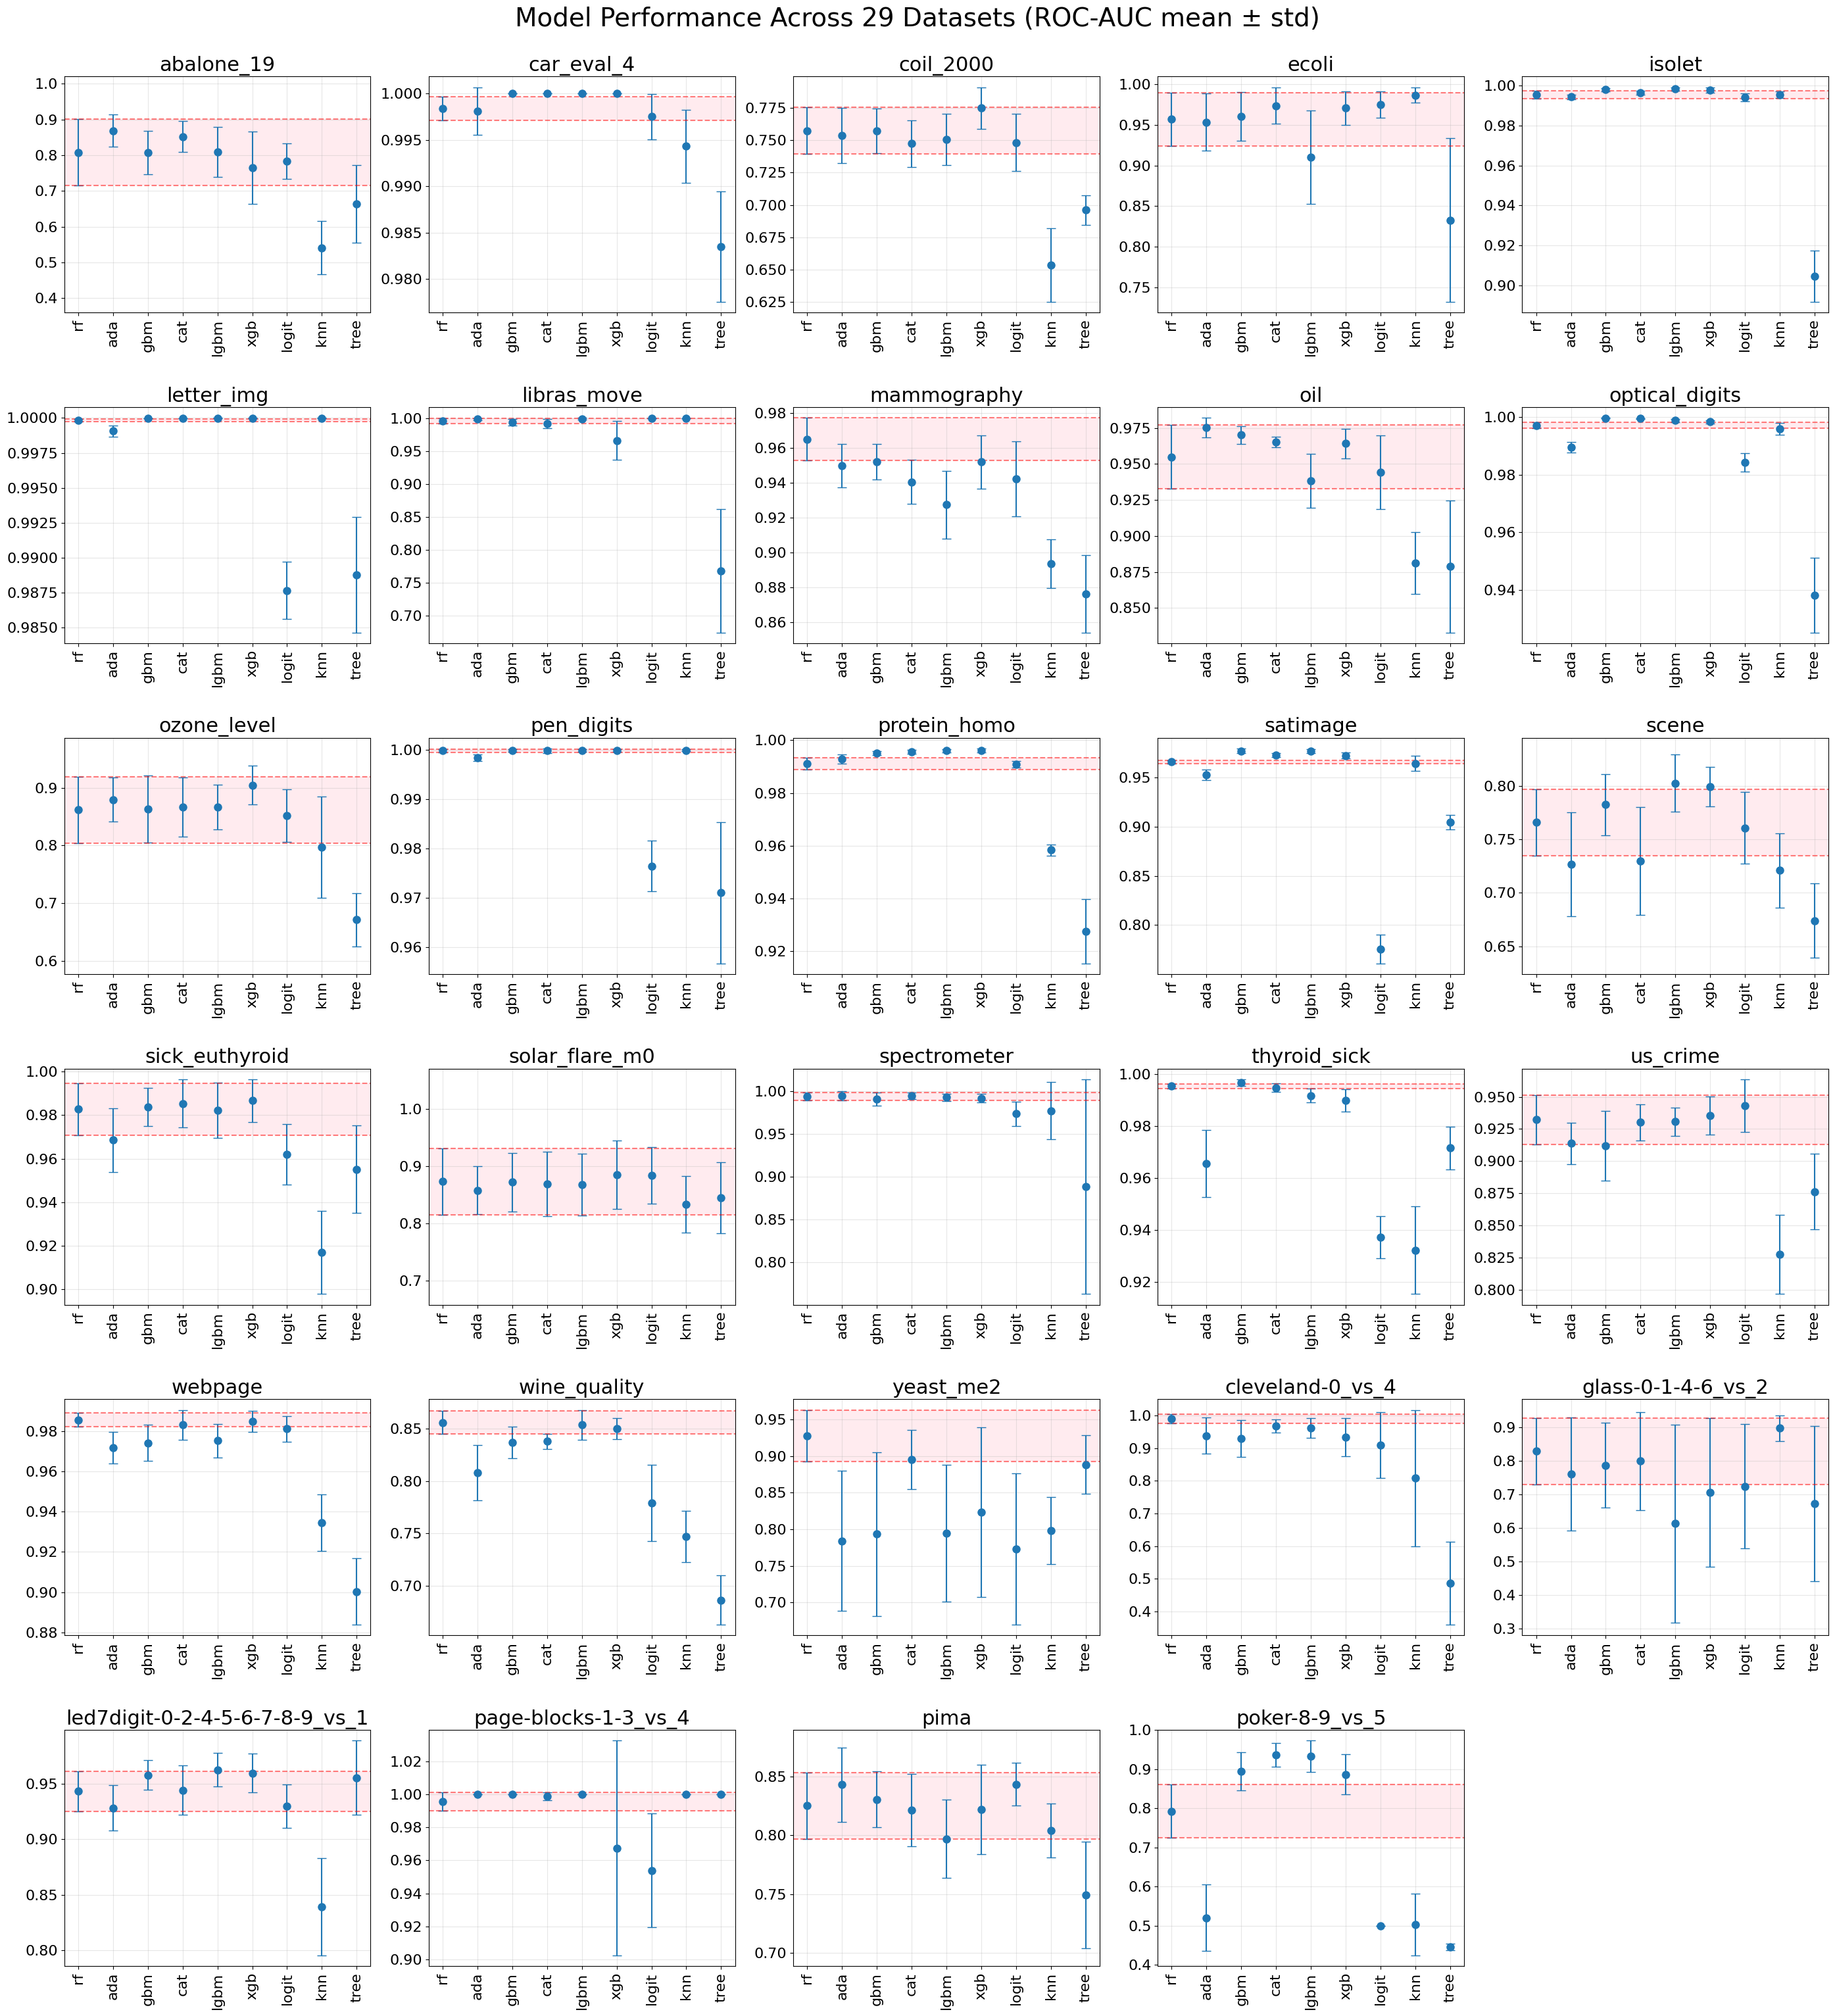

In [7]:
# Create figure with 34 subplots
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(28, 30))  
axes = axes.ravel()  # Flatten for easy iteration

# Loop through each DataFrame
for i, data in enumerate(datasets):
    df = create_df(scores_dict, data, models)
    
    ax = axes[i]
    
    # Extract data
    cls = df.index
    means = df.iloc[:, 0]
    stds = df.iloc[:, 1]

    ref = df.iloc[0, 0]
    upper = df.iloc[0, 0] + df.iloc[0, 1]
    lower = df.iloc[0, 0] - df.iloc[0, 1]
    
    # Create errorbar plot
    ax.errorbar(x=cls, y=means, yerr=stds, 
               fmt='o', capsize=5, markersize=8)
    
    # Customize subplot
    ax.set_title(data, fontsize=22)
    ylims = compute_ylim(means, stds, upper, lower)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(True, alpha=0.3)
    
    # Add horizontal line at RF error bars
    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    
    # color area between error bars
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.suptitle('Model Performance Across 29 Datasets (ROC-AUC mean ± std)', fontsize=28, y=1.02)
plt.savefig('../../mlid-book/resources/ch1/model-performance-comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Chapter 2, ranking vs scoring metrics

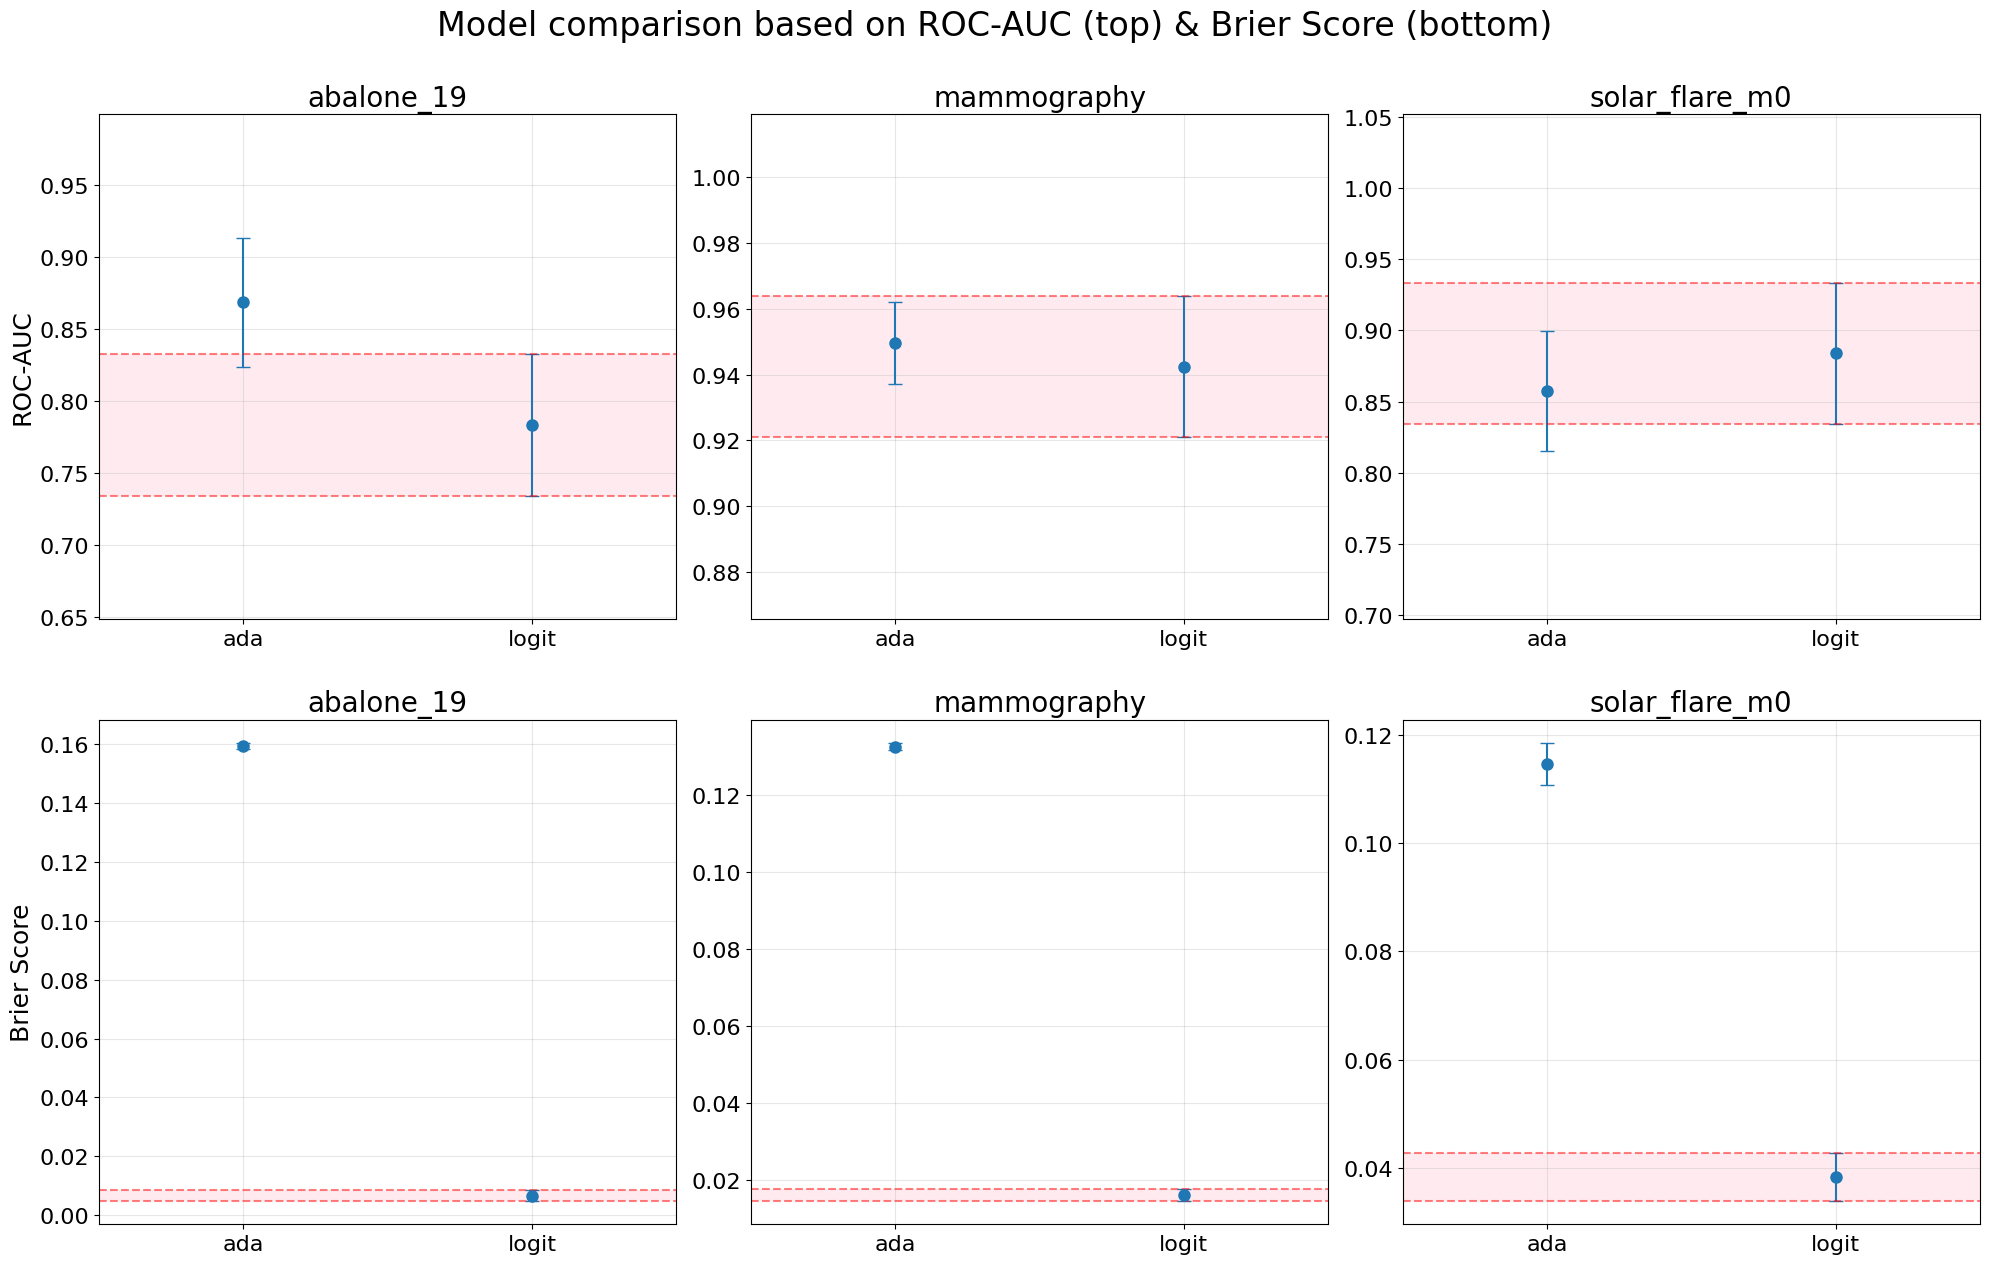

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))

datasets = ["abalone_19", "mammography", "solar_flare_m0"]
models = ["ada", "logit"]

# Row 0: ROC-AUC, Row 1: Brier Score
for row, (metric_name, col_mean, col_std) in enumerate([
    ("ROC-AUC", 0, 1),
    ("Brier Score", 14, 15)
]):
    for col, data in enumerate(datasets):
        df = create_df(scores_dict, data, models)
        ax = axes[row, col]

        cls = df.index
        means = df.iloc[:, col_mean]
        stds  = df.iloc[:, col_std]

        # Find logit row for the highlight band
        logit_idx = cls.get_loc("logit")
        upper = means.iloc[logit_idx] + stds.iloc[logit_idx]
        lower = means.iloc[logit_idx] - stds.iloc[logit_idx]

        # Error bar plot
        ax.errorbar(x=cls, y=means, yerr=stds,
                    fmt='o', capsize=5, markersize=8)

        # Highlight logit error bar band
        ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
        ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
        ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

        # Labels and formatting
        ax.set_title(f"{data}", fontsize=20)
        if col == 0:
            ax.set_ylabel(metric_name, fontsize=18)

        ylims = compute_ylim(means, stds, upper, lower)
        ax.set_ylim(ylims)
        ax.tick_params(axis='y', labelsize=16)
        ax.tick_params(axis='x', labelsize=16)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-0.5, len(cls) - 0.5)


plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.suptitle('Model comparison based on ROC-AUC (top) & Brier Score (bottom)', fontsize=24, y=1.05)
plt.savefig('../../mlid-book/resources/ch2/ch2-fig2.png', dpi=300, bbox_inches='tight')
plt.show()

## Chapter 2, ROC curves

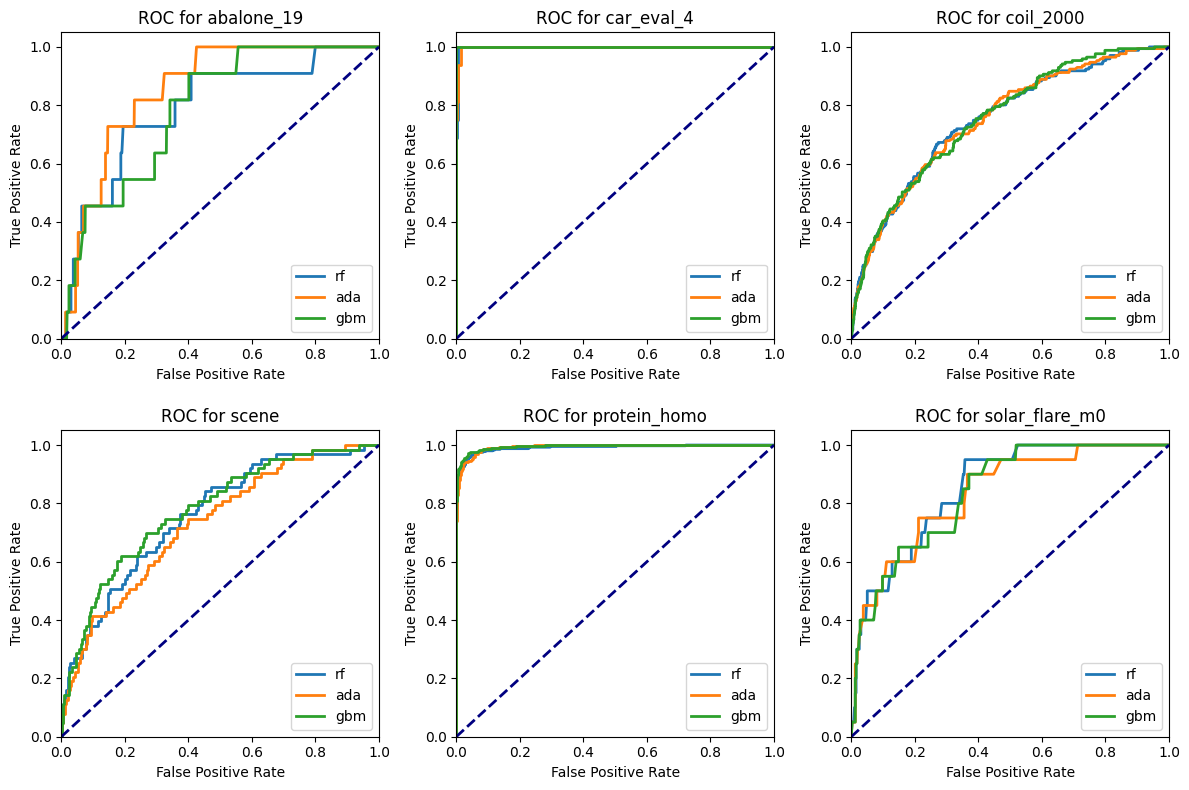

In [9]:
# Create figure with 34 subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
axes = axes.ravel()  # Flatten for easy iteration

datasets = [
    "abalone_19",
    "car_eval_4",
    "coil_2000",
    "scene",
    "protein_homo",
    "solar_flare_m0",
]

models = ["rf", "ada", "gbm"]

# Loop through each DataFrame
for i, data in enumerate(datasets):
    ax = axes[i]

    # load data
    X_train, X_test, y_train, y_test = load_dataset(data)
    
    # For each model type
    for estimator in models:
        
        # load model
        search = joblib.load(f"../models/ensembles/{data}_{estimator}.pkl")

        # obtain probability
        prob = search.predict_proba(X_test)[:, 1]
        
        # Plot ROC curve
        fpr, tpr, _ =  roc_curve(y_test, prob)
        ax.plot(fpr, tpr, lw=2, label=f'{estimator}')
    
    # Format the plot
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC for {data}')
    ax.legend(loc="lower right")

# Hide empty subplots if any
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.savefig('../../mlid-book/resources/ch2/ch2-fig12.png', dpi=300, bbox_inches='tight')
plt.show()

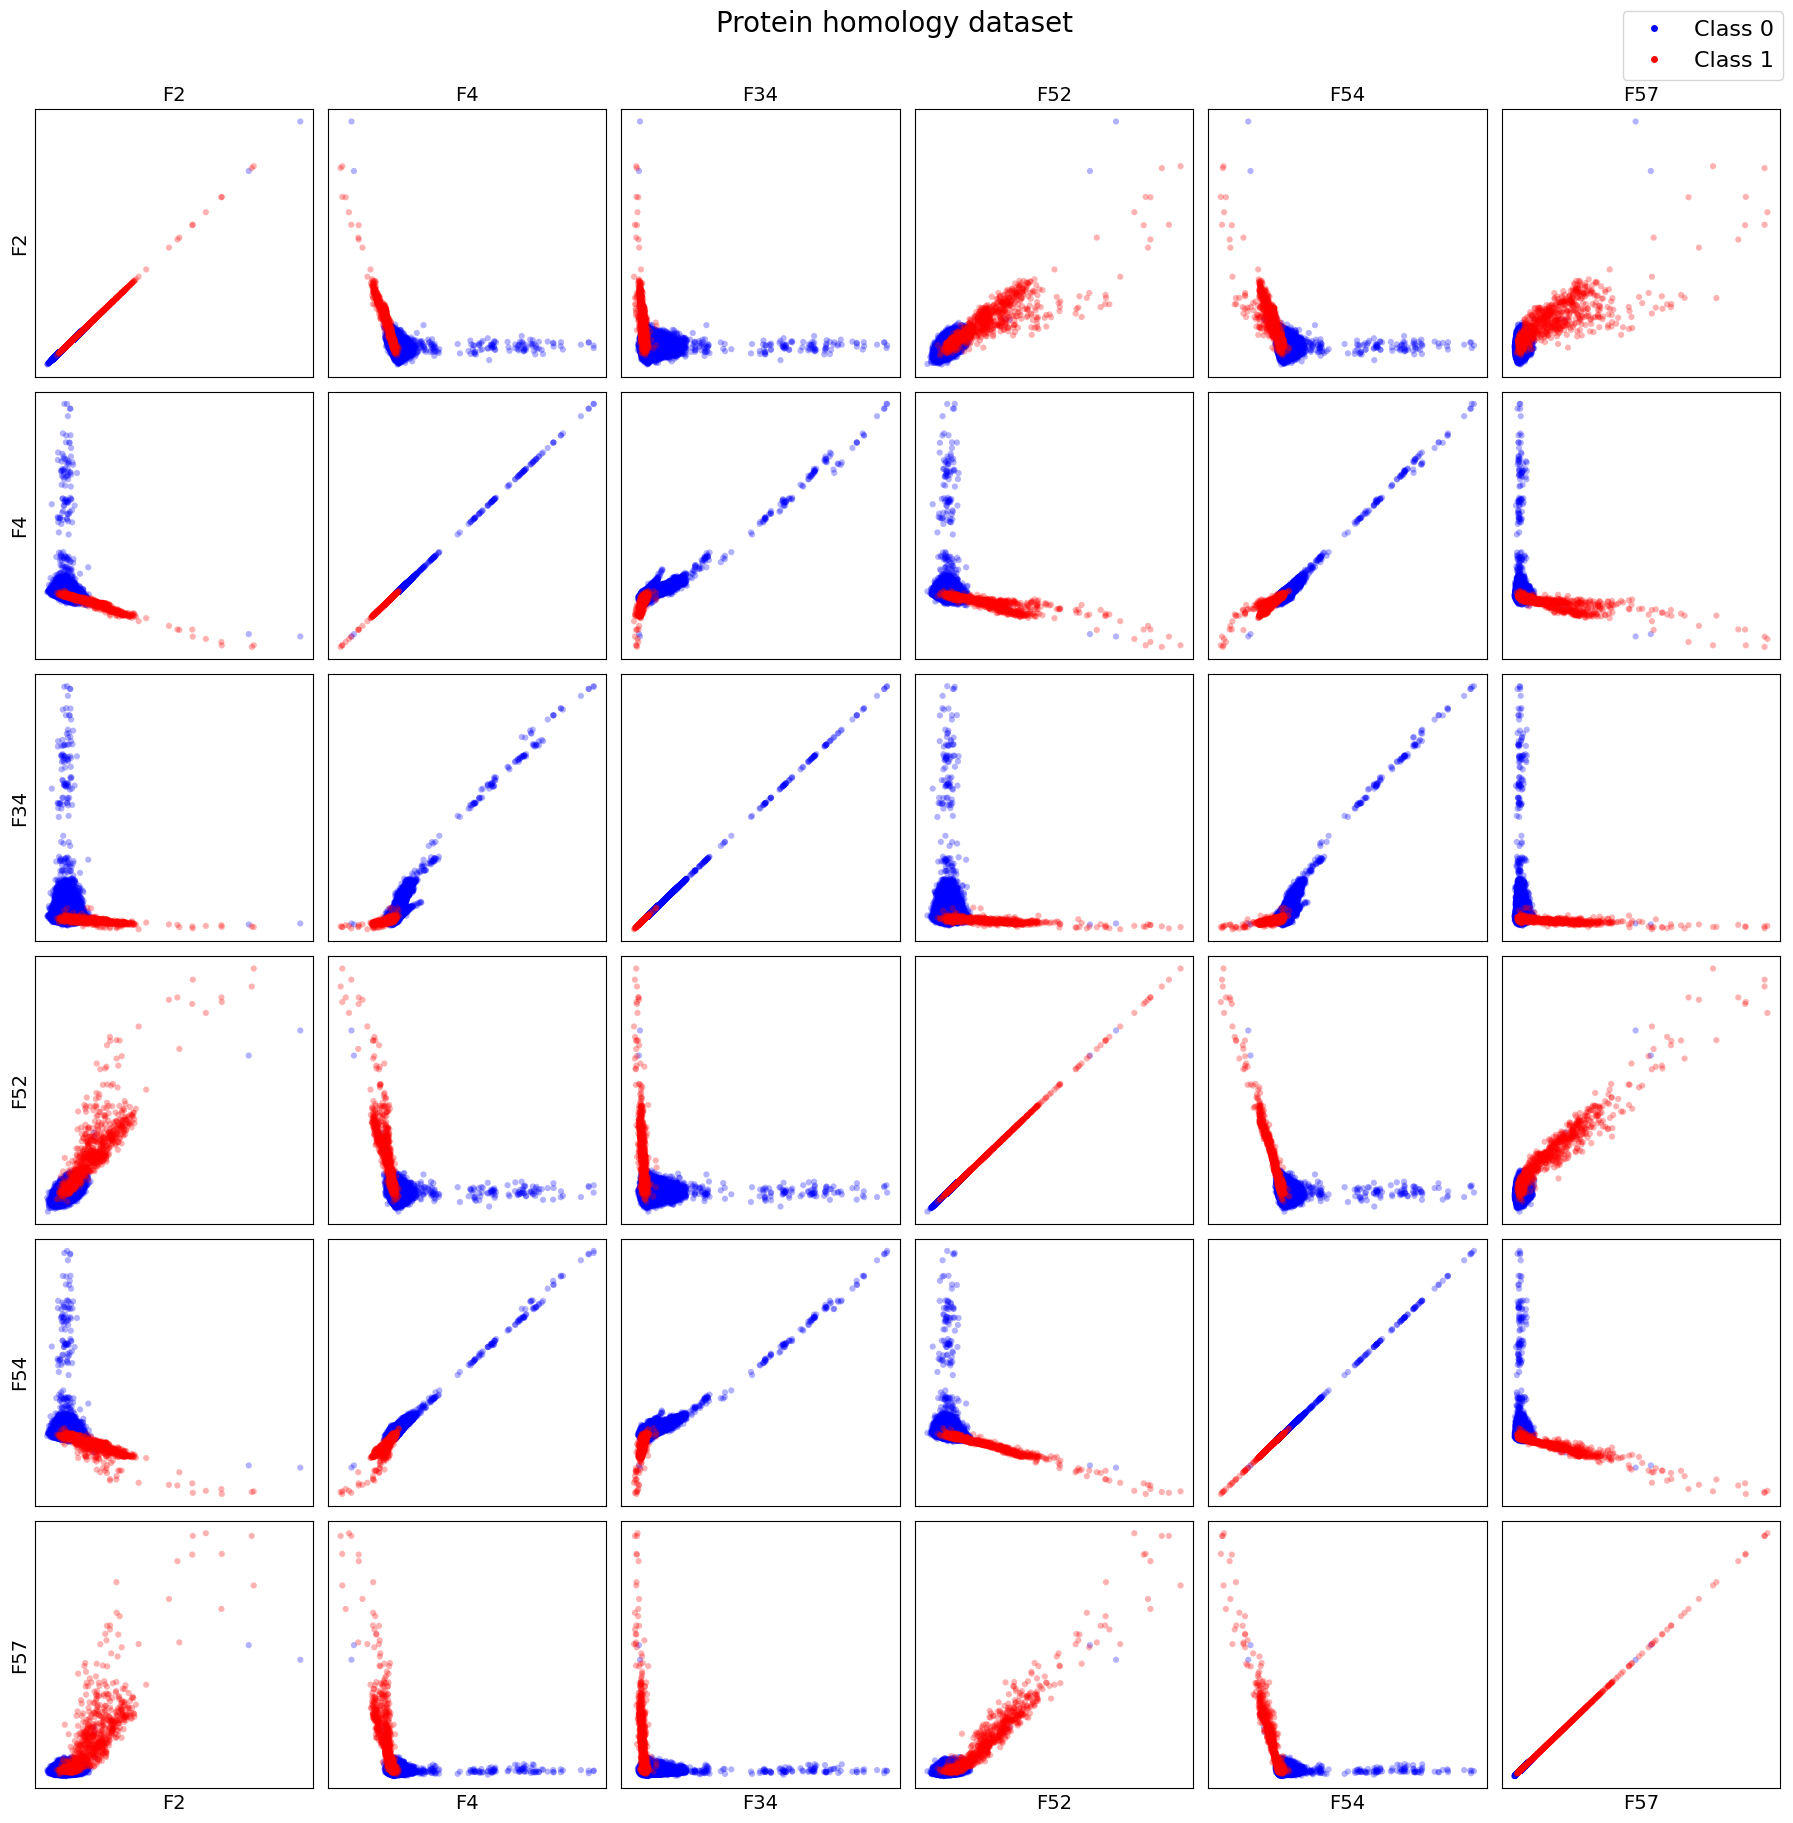

In [10]:
from sklearn.metrics import roc_auc_score

dataset = "protein_homo"
threshold = 0.9

X_train, X_test, y_train, y_test = load_dataset(dataset)

# find good features
good_features = []
for j in range(X_train.shape[1]):
    col = X_train.iloc[:, j] if hasattr(X_train, "iloc") else X_train[:, j]
    auc = roc_auc_score(y_train, col)
    auc = max(auc, 1 - auc)
    if auc >= threshold:
        feat_name = X_train.columns[j] if hasattr(X_train, "columns") else j
        good_features.append((feat_name, round(auc, 3)))


# Scatter plots
feat_names = [f[0] for f in good_features]
n = len(feat_names)
fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))
if n == 1:
    axes = np.array([[axes]])
for i, fi in enumerate(feat_names):
    for j, fj in enumerate(feat_names):
        ax = axes[i, j]
        for label, color in zip([0, 1], ["blue", "red"]):
            mask = y_train == label
            xi = X_train.iloc[mask, X_train.columns.get_loc(fi)] if hasattr(X_train, "iloc") else X_train[mask, fi]
            xj = X_train.iloc[mask, X_train.columns.get_loc(fj)] if hasattr(X_train, "iloc") else X_train[mask, fj]
            ax.scatter(xj, xi, c=color, edgecolor="none", alpha=0.3, s=20)
        if i == n - 1:
            ax.set_xlabel(f"F{fj}", fontsize=14)
        if j == 0:
            ax.set_ylabel(f"F{fi}", fontsize=14)
        if i == 0:
            ax.set_title(f"F{fj}", fontsize=14)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, label=f"Class {l}")
           for l, c in zip([0, 1], ["blue", "red"])]
fig.legend(handles=handles, loc="upper right", fontsize=16)
plt.suptitle("Protein homology dataset", y=1.01, fontsize=20)
plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch2/ch2-fig13.png', dpi=300, bbox_inches='tight')
plt.show()

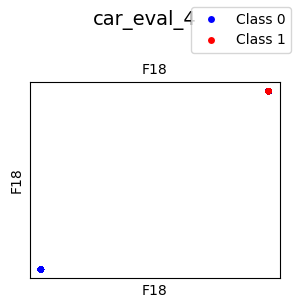

In [11]:
dataset = "car_eval_4"
threshold = 0.8

X_train, X_test, y_train, y_test = load_dataset(dataset)

# find good features
good_features = []
for j in range(X_train.shape[1]):
    col = X_train.iloc[:, j] if hasattr(X_train, "iloc") else X_train[:, j]
    auc = roc_auc_score(y_train, col)
    auc = max(auc, 1 - auc)
    if auc >= threshold:
        feat_name = X_train.columns[j] if hasattr(X_train, "columns") else j
        good_features.append((feat_name, round(auc, 3)))


# Scatter plots
feat_names = [f[0] for f in good_features]
n = len(feat_names)
fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))
if n == 1:
    axes = np.array([[axes]])
for i, fi in enumerate(feat_names):
    for j, fj in enumerate(feat_names):
        ax = axes[i, j]
        for label, color in zip([0, 1], ["blue", "red"]):
            mask = y_train == label
            xi = X_train.iloc[mask, X_train.columns.get_loc(fi)] if hasattr(X_train, "iloc") else X_train[mask, fi]
            xj = X_train.iloc[mask, X_train.columns.get_loc(fj)] if hasattr(X_train, "iloc") else X_train[mask, fj]
            ax.scatter(xj, xi, c=color, edgecolor="none", alpha=0.3, s=20)
        if i == n - 1:
            ax.set_xlabel(f"F{fj}", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"F{fi}", fontsize=10)
        if i == 0:
            ax.set_title(f"F{fj}", fontsize=10)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, label=f"Class {l}")
           for l, c in zip([0, 1], ["blue", "red"])]
fig.legend(handles=handles, loc="upper right", fontsize=10)
plt.suptitle(f"{dataset}", y=1.01, fontsize=14)
plt.tight_layout()
# plt.savefig('../../mlid-book/resources/ch2/ch2-fig12.png', dpi=300, bbox_inches='tight')
plt.show()

## Chapter 2, PR vs ROC curves

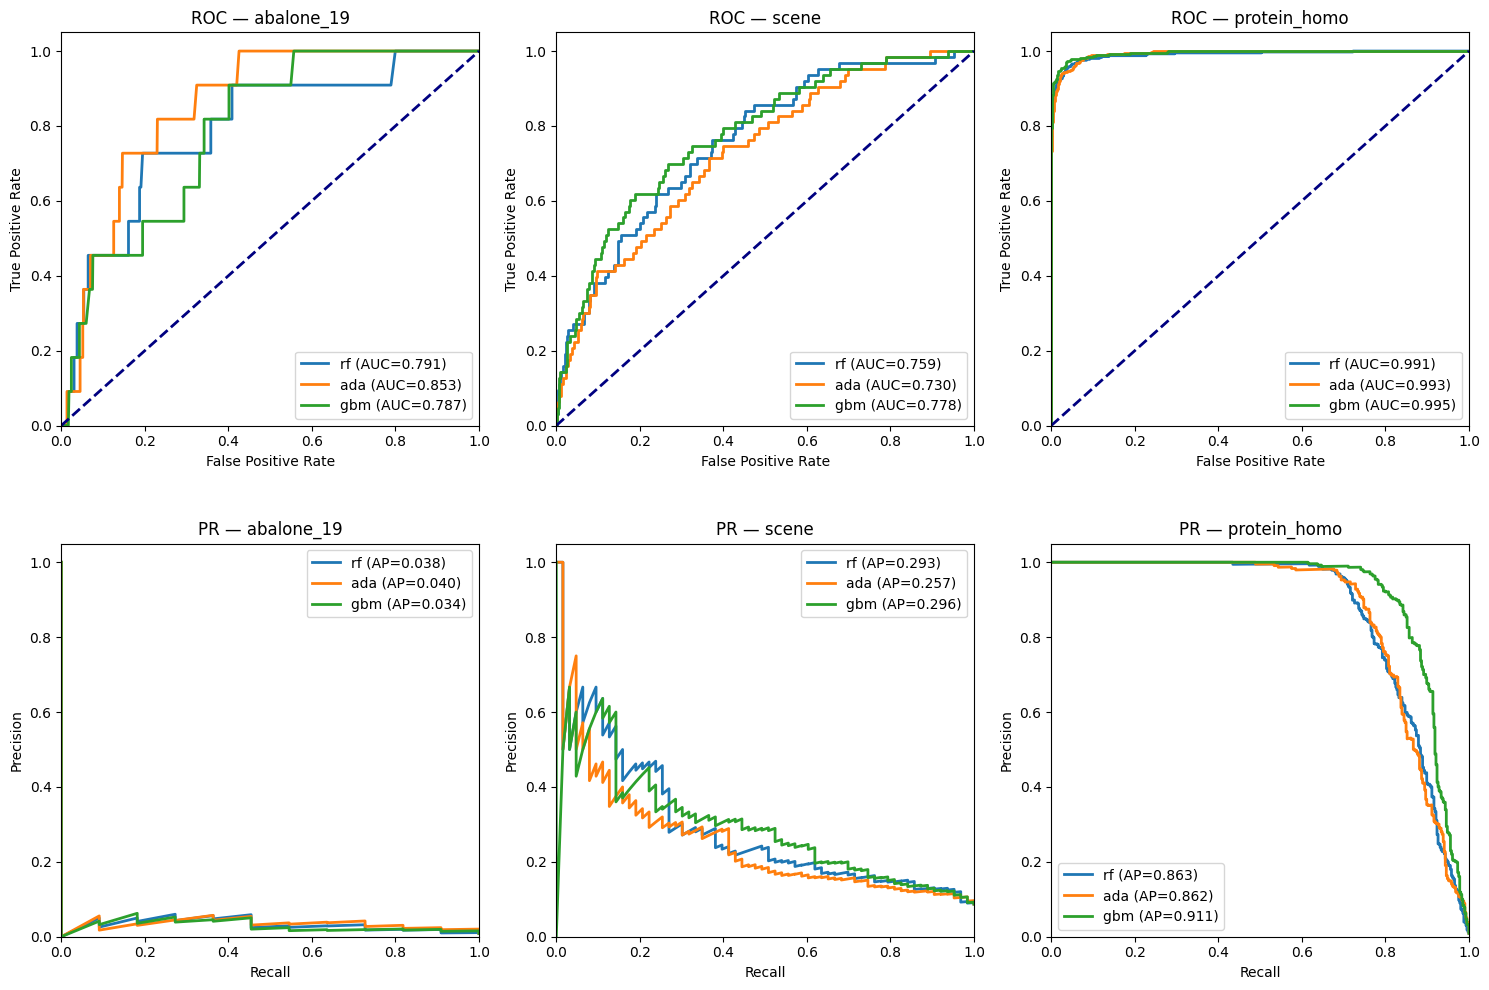

In [12]:
from sklearn.metrics import average_precision_score

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

datasets = ["abalone_19", "scene", "protein_homo"]
models   = ["rf", "ada", "gbm"]

for col, data in enumerate(datasets):
    X_train, X_test, y_train, y_test = load_dataset(data)

    for estimator in models:
        search = joblib.load(f"../models/ensembles/{data}_{estimator}.pkl")
        prob   = search.predict_proba(X_test)[:, 1]
        
        roc_auc = roc_auc_score(y_test, prob)
        pr_auc  = average_precision_score(y_test, prob)

        # ROC — top row
        fpr, tpr, _ = roc_curve(y_test, prob)
        axes[0, col].plot(fpr, tpr, lw=2, label=f"{estimator} (AUC={roc_auc:.3f})")

        # PR — bottom row
        prec, rec, _ = precision_recall_curve(y_test, prob)
        axes[1, col].plot(rec, prec, lw=2, label=f"{estimator} (AP={pr_auc:.3f})")
        
    # ROC formatting
    axes[0, col].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    axes[0, col].set(xlim=[0, 1], ylim=[0, 1.05],
                     xlabel="False Positive Rate", ylabel="True Positive Rate",
                     title=f"ROC — {data}")
    axes[0, col].legend(loc="lower right")

    # PR formatting
    axes[1, col].set(xlim=[0, 1], ylim=[0, 1.05],
                     xlabel="Recall", ylabel="Precision",
                     title=f"PR — {data}")
    axes[1, col].legend(loc="upper right")

axes[1, 2].legend(loc="lower left")
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.savefig("../../mlid-book/resources/ch2/ch2-fig16.png", dpi=300, bbox_inches="tight")
plt.show()